# AN2DL - Homework 1

## 1 - Libraries and Dataset Import


In [1]:
#%pip install tensorflow==2.17 keras==3.4.1
import numpy as np
import random
import time
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

import os 
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"
#os.environ["CUDA_VISIBLE_DEVICES"]="0"

import tensorflow as tf
import keras as tfk
import keras_cv
from keras import layers as kl
from keras_cv import layers as kcvl
from keras import mixed_precision

#mixed_precision.set_global_policy('mixed_float16')

tf.config.optimizer.set_jit(True)  # Enable XLA

print("GPUs Available: ", tf.config.list_physical_devices('GPU'))
print(f"TensorFlow version {tf.__version__}")

np.random.seed(42)
tf.random.set_seed(42)

2024-11-13 12:06:49.707982: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-11-13 12:06:49.720268: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-13 12:06:49.735286: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-13 12:06:49.739343: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-13 12:06:49.751587: I tensorflow/core/platform/cpu_feature_guar

GPUs Available:  [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version 2.17.0


In [2]:
data = np.load('training_set.npz')

X = data['images']
y = data['labels']
print(X.shape, y.shape)

(13759, 96, 96, 3) (13759, 1)


## 2 - Check for missing, duplicate values and class distribution

In [3]:
missing_targets = np.isnan(y.flatten()).any()

if not missing_targets :
    print("There are no missing or NaN values in the target vector.")

There are no missing or NaN values in the target vector.


In [4]:
# Duplicates count and removal
reshaped_X = X.reshape(X.shape[0], -1) # Reshape each image to a 1D vector and stack them for comparison

unique_X, unique_indices = np.unique(reshaped_X, axis=0, return_index=True) # Find unique images and their indices

# Select unique images and labels
X_unique = X[unique_indices]
y_unique = y[unique_indices]

print(f'Labels reduced from {len(y)} to {len(y_unique)}')
# (should output a reduction from 13759 to 11953)

Labels reduced from 13759 to 11953


In [5]:
X = X_unique
y = y_unique

# Define a mapping of labels to their corresponding digit names
labels = {0:'Basophil', 1:'Eosinophil', 2:'Erythroblast', 3:'Immature granulocytes', 4:'Lymphocyte', 5:'Monocyte', 6:'Neutrophil', 7:'Platelet'}

# Save unique labels
unique_labels = list(labels.values())
'''
# Display a sample of images from the training-validation dataset
num_img = 10
random_indices = random.sample(range(len(X)), num_img)

fig, axes = plt.subplots(1, num_img, figsize=(20, 20))

# Iterate through the selected number of images
for i, idx in enumerate(random_indices):
    ax = axes[i % num_img]
    ax.imshow(np.squeeze(X[idx]), vmin=0., vmax=1.)
    ax.set_title(f'{labels[y[idx][0]]}')
    ax.axis('off')

# Adjust layout and display the images
plt.tight_layout()
plt.show()

labels_list, counts = np.unique(y.flatten(), return_counts=True)
classes = [labels[label] for label in labels_list]
df = pd.DataFrame({'Class': classes, 'Count': counts})

# Plot the barplot
plt.figure(figsize=(10, 6))
sns.barplot(x=classes, y=counts)
plt.title('Class distribution in the Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=45)  # Adjust rotation for readability if needed
plt.show()'''

"\n# Display a sample of images from the training-validation dataset\nnum_img = 10\nrandom_indices = random.sample(range(len(X)), num_img)\n\nfig, axes = plt.subplots(1, num_img, figsize=(20, 20))\n\n# Iterate through the selected number of images\nfor i, idx in enumerate(random_indices):\n    ax = axes[i % num_img]\n    ax.imshow(np.squeeze(X[idx]), vmin=0., vmax=1.)\n    ax.set_title(f'{labels[y[idx][0]]}')\n    ax.axis('off')\n\n# Adjust layout and display the images\nplt.tight_layout()\nplt.show()\n\nlabels_list, counts = np.unique(y.flatten(), return_counts=True)\nclasses = [labels[label] for label in labels_list]\ndf = pd.DataFrame({'Class': classes, 'Count': counts})\n\n# Plot the barplot\nplt.figure(figsize=(10, 6))\nsns.barplot(x=classes, y=counts)\nplt.title('Class distribution in the Dataset')\nplt.xlabel('Class')\nplt.ylabel('Count')\nplt.xticks(rotation=45)  # Adjust rotation for readability if needed\nplt.show()"

In [6]:
'''
class_counts = pd.Series(y.flatten()).value_counts()

imbalance_ratio = class_counts.max() / class_counts.min()
print("Imbalance Ratio:", imbalance_ratio) # Between 1.5 and 4 considered moderately imbalanced

proportions = class_counts / class_counts.sum()
gini_index = 1 - sum(proportions ** 2)
print("Gini Index:", gini_index) # Between 0.1 and 0.25 considered moderately imbalanced
'''

'\nclass_counts = pd.Series(y.flatten()).value_counts()\n\nimbalance_ratio = class_counts.max() / class_counts.min()\nprint("Imbalance Ratio:", imbalance_ratio) # Between 1.5 and 4 considered moderately imbalanced\n\nproportions = class_counts / class_counts.sum()\ngini_index = 1 - sum(proportions ** 2)\nprint("Gini Index:", gini_index) # Between 0.1 and 0.25 considered moderately imbalanced\n'

## 3 - Split dataset into Train, Test and Validation sets while maintaining the distribution

In [7]:
from sklearn.utils.class_weight import compute_class_weight

# Split data into training, test and validation sets, maintaining class distribution
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1, stratify=y_train_val)

# Print the shapes of the resulting datasets
print("Training Data Shape:", X_train.shape)
print("Training Label Shape:", y_train.shape)
print("Test Data Shape:", X_test.shape)
print("Test Label Shape:", y_test.shape)
print("Validation Data Shape:", X_val.shape)
print("Validation Label Shape:", y_val.shape)

# Convert labels to categorical format using one-hot encoding
y_train = tfk.utils.to_categorical(y_train)
y_val = tfk.utils.to_categorical(y_val)
y_test = tfk.utils.to_categorical(y_test)

Training Data Shape: (8605, 96, 96, 3)
Training Label Shape: (8605, 1)
Test Data Shape: (2391, 96, 96, 3)
Test Label Shape: (2391, 1)
Validation Data Shape: (957, 96, 96, 3)
Validation Label Shape: (957, 1)


## 4 - Image Augmentation

In [8]:
value_range=(0, 255)

# Define the augmentation pipeline
layers = kcvl.RandAugment.get_standard_policy(value_range=value_range, magnitude=0.1, magnitude_stddev=0.2)

# Add additional augmentations
layers.extend([
    kl.GaussianNoise(0.1),  
    kcvl.GridMask(),            
    kcvl.RandomHue(factor=0.2, value_range=value_range),          
    kcvl.RandomSaturation(factor=0.5),   
    kcvl.RandomColorDegeneration(factor=1.0)
])
cut_mix = kcvl.CutMix(alpha=0.01)
mix_up = kcvl.MixUp()

pipeline = kcvl.RandomAugmentationPipeline(
    layers=layers,
    augmentations_per_image=3  # Randomly apply 3 augmentations from the list
)

def cut_mix_and_mix_up(samples):
    # Uncommenting these lines, plotting will we incoherent for some reason
    # samples = cut_mix(samples, training=True)
    # samples = mix_up(samples, training=True)
    return samples

def apply_pipeline(inputs):
    inputs["images"] = pipeline(inputs["images"])  # Apply RandomAugmentationPipeline
    inputs = cut_mix_and_mix_up(inputs)  # Apply CutMix and MixUp
    return inputs

I0000 00:00:1731496023.105989   19783 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731496023.116349   19783 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731496023.119972   19783 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1731496023.264549   19783 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

In [ ]:
def plot_augmented_images(X_train, y_train, num_images, num_augmentations):
    batch = X_train[:num_images]  # Take a batch of images for visualization
    labels_batch = y_train[:num_images]
    
    fig, axes = plt.subplots(num_augmentations + 1, num_images, figsize=(20, 10))  # 4 rows, 10 columns

    # Display original images in the first row
    for i in range(num_images):
        original_image = batch[i].astype("uint8")  # Convert to uint8 for display
        axes[0, i].imshow(original_image)
        axes[0, i].axis("off")
        if i == 0:
            axes[0, i].set_title("Original", fontsize=12)
        else:
            axes[0, i].set_title("")

    # Display augmentations in subsequent rows
    for j in range(num_augmentations):
        augmented_batch = apply_pipeline({
            "images": tf.convert_to_tensor(batch), 
            "labels": tf.convert_to_tensor(labels_batch, dtype=tf.float32)
        })
        for i in range(num_images):
            augmented_image = tf.clip_by_value(augmented_batch["images"][i], 0, 255)  # Ensure values are in display range
            axes[j + 1, i].imshow(augmented_image.numpy().astype("uint8"))
            axes[j + 1, i].axis("off")
            if i == 0:
                axes[j + 1, i].set_title(f"Augmentation {j + 1}", fontsize=12)
            else:
                axes[j + 1, i].set_title("")

    plt.tight_layout()
    plt.show()

# Plot 10 images with 3 augmented versions each
plot_augmented_images(X_train, y_train, 10, 3)

In [ ]:
batch_size = 64

train_dataset = (
    tf.data.Dataset.from_tensor_slices((X_train, y_train))
    .batch(batch_size)
    .map(lambda x, y: (apply_pipeline({"images": x, "labels": tf.cast(y, tf.float32)})["images"], y), num_parallel_calls=tf.data.AUTOTUNE)
    .map(lambda x, y: (x / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images to [0, 1]
    .prefetch(tf.data.AUTOTUNE)
)

# Apply normalization to val_dataset
val_dataset = (
    tf.data.Dataset.from_tensor_slices((X_val, y_val))
    .batch(batch_size)
    .map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y), num_parallel_calls=tf.data.AUTOTUNE)  # Normalize images to [0, 1]
    .prefetch(tf.data.AUTOTUNE)
)

# 5. Training

In [ ]:
from Models.base_model import build_model

input_shape = X_train.shape[1:]
output_shape = y_train.shape[1]

print("Input Shape:", input_shape)
print("Output Shape:", output_shape)

learning_rate = 0.001

model = build_model(input_shape, output_shape, learning_rate)
model.summary()
#tfk.utils.plot_model(model, expand_nested=True, show_trainable=True, show_shapes=True, dpi=70)

Input Shape: (96, 96, 3)
Output Shape: 8


Model: "build_model_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input (InputLayer)              │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_conv1 (SeparableConv2D)     │ (None, 96, 96, 32)     │           155 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn1 (BatchNormalization)        │ (None, 96, 96, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act1 (Activation)               │ (None, 96, 96, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp1 (MaxPooling2D)              │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_conv2 (SeparableConv2D)     │ (None, 48, 48, 64)     │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn2 (BatchNormalization)        │ (None, 48, 48, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act2 (Activation)               │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp2 (MaxPooling2D)              │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sep_conv3 (SeparableConv2D)     │ (None, 24, 24, 128)    │         8,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn3 (BatchNormalization)        │ (None, 24, 24, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ act3 (Activation)               │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mp3 (MaxPooling2D)              │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 8)              │         1,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax (Activation)            │ (None, 8)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,379 (52.26 KB)

 Trainable params: 12,931 (50.51 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
epochs = 20

# Create an EarlyStopping callback
early_stopping = tfk.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=10, restore_best_weights=True)

steps_per_epoch = len(X_train) // batch_size
print(f"Steps per epoch: {steps_per_epoch}")
effective_size = steps_per_epoch * batch_size * epochs
print(f"Effective number of images seen by the model (with augmentation): {effective_size}")

Steps per epoch: 134
Effective number of images seen by the model (with augmentation): 171520


In [ ]:
start_time = time.time()

#mixed_precision.set_global_policy('mixed_float16')

history = model.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[early_stopping]
    #class_weight=class_weights
).history

print("--- %s seconds ---" % (time.time() - start_time))

# Calculate and print the final validation accuracy
final_val_accuracy = round(max(history['val_accuracy'])* 100, 2)
print(f'Final validation accuracy: {final_val_accuracy}%')

# Save the trained model to a file with the accuracy included in the filename
model_filename = 'Submissions/base_model.keras'
model.save(model_filename)

# Delete the model to free up resources
del model

Epoch 1/20


2024-11-13 12:05:28.986171: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1731495930.353709   17191 service.cc:146] XLA service 0x12f9b370 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1731495930.353753   17191 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
2024-11-13 12:05:30.373543: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 8900
I0000 00:00:1731495930.406163   17191 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2024-11-13 12:05:32.409984: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


135/135 ━━━━━━━━━━━━━━━━━━━━ 32s 138ms/step - accuracy: 0.1842 - loss: 2.3246 - val_accuracy: 0.1369 - val_loss: 2.0691
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/step - accuracy: 0.3055 - loss: 1.8743 - val_accuracy: 0.1390 - val_loss: 2.0459
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.3573 - loss: 1.7326 - val_accuracy: 0.2591 - val_loss: 1.7157
Epoch 4/20
 47/135 ━━━━━━━━━━━━━━━━━━━━ 5s 60ms/step - accuracy: 0.4057 - loss: 1.6122

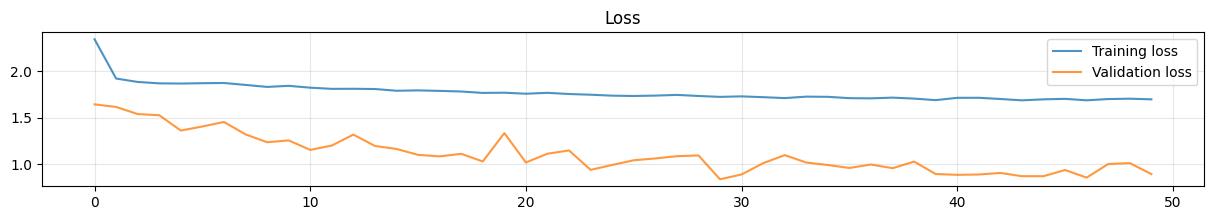

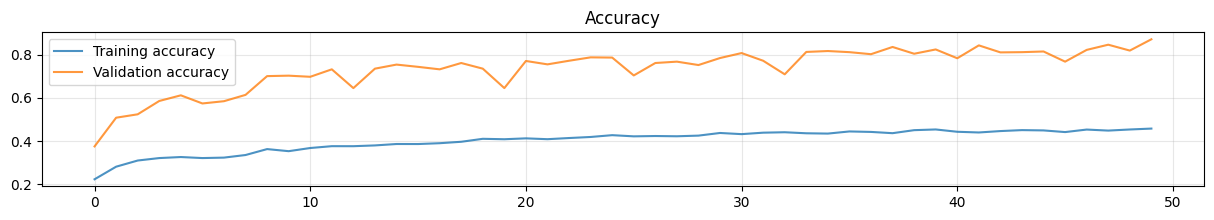

In [ ]:
# Plot training and validation loss
plt.figure(figsize=(15, 2))
plt.plot(history['loss'], label='Training loss', alpha=.8)
plt.plot(history['val_loss'], label='Validation loss', alpha=.8)
plt.title('Loss')
plt.legend()
plt.grid(alpha=.3)

# Plot training and validation accuracy
plt.figure(figsize=(15, 2))
plt.plot(history['accuracy'], label='Training accuracy', alpha=.8)
plt.plot(history['val_accuracy'], label='Validation accuracy', alpha=.8)
plt.title('Accuracy')
plt.legend()
plt.grid(alpha=.3)
plt.show()


/home/teo/Desktop/LabANN/venvANNUbu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer', because it has 22 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
/home/teo/Desktop/LabANN/venvANNUbu/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:576: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 0 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Predictions Shape: (2391, 8)
Accuracy score over the test set: 0.8795
Precision score over the test set: 0.8903
Recall score over the test set: 0.8795
F1 score over the test set: 0.8798


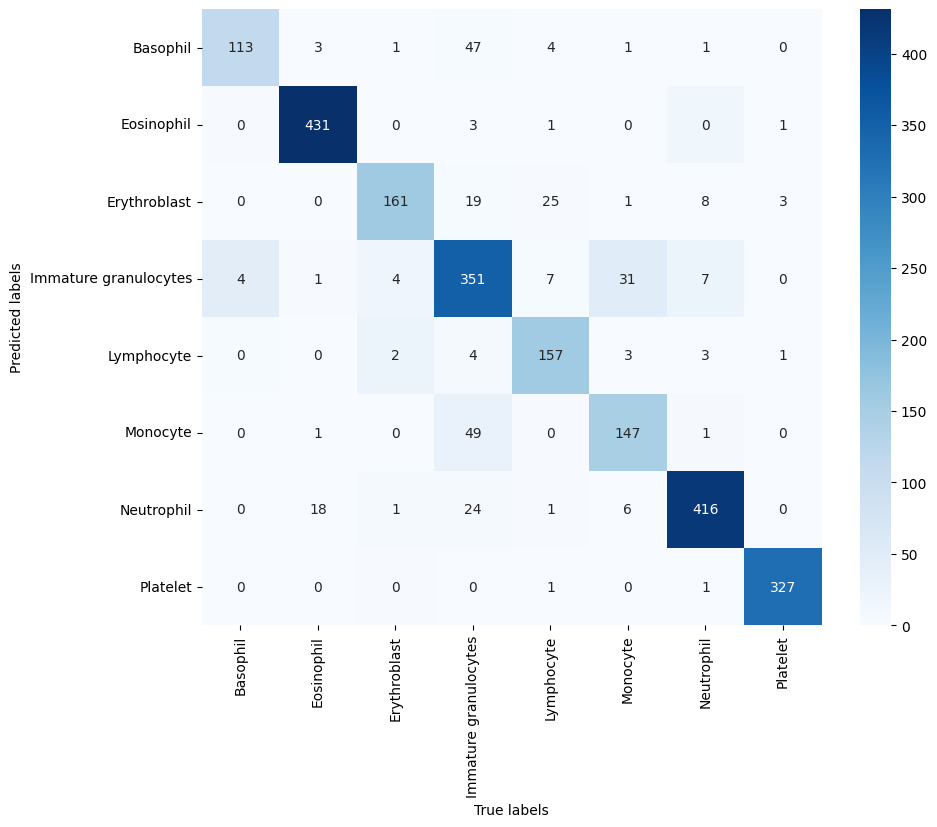

In [ ]:
model = tfk.models.load_model('Submissions/base_model.keras')
# Predict labels for the entire test set
X_test = (X_test / 255).astype('float32')
predictions = model.predict(X_test, verbose=0)

print("Predictions Shape:", predictions.shape)

# Convert predictions to class labels
pred_classes = np.argmax(predictions, axis=-1)

# Extract ground truth classes
true_classes = np.argmax(y_test, axis=-1)

accuracy = accuracy_score(true_classes, pred_classes)
print(f'Accuracy score over the test set: {round(accuracy, 4)}')

precision = precision_score(true_classes, pred_classes, average='weighted')
print(f'Precision score over the test set: {round(precision, 4)}')

recall = recall_score(true_classes, pred_classes, average='weighted')
print(f'Recall score over the test set: {round(recall, 4)}')

f1 = f1_score(true_classes, pred_classes, average='weighted')
print(f'F1 score over the test set: {round(f1, 4)}')

cm = confusion_matrix(true_classes, pred_classes)

# Combine numbers and percentages into a single string for annotation
annot = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm.T, annot=annot, fmt='', xticklabels=list(labels.values()), yticklabels=list(labels.values()), cmap='Blues')
plt.xlabel('True labels')
plt.ylabel('Predicted labels')
plt.show()